# MGSC 661 - Predicting Movie Opening-Weekend Revenue


 

## Setup

In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro

from ISLP.models import (ModelSpec as MS,
                         summarize)

In [38]:

df = pd.read_excel('movie_training_data_student.xlsx', sheet_name = 'Training_Data')
df.head()

,movie_id,title,release_date,release_year,release_month,release_quarter,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,...,holiday_release,source_dataset,source_url,audience_score,domestic_box_office_musd,foreign_box_office_musd,worldwide_box_office_musd,opening_revenue_per_theater_kusd,opening_budget_recovery_pct,worldwide_budget_recovery_pct
0,TRN-0001,Escape Room,2019-01-04,2019,1,Q1,18.238172,9.0,2717,109.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Escape-Room-...,54.0,57.00,98.61,155.62,6.712614,2.026464,17.291111
1,TRN-0002,A Dog’s Way Home,2019-01-11,2019,1,Q1,11.251263,61.0,3090,102.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Dogs-Way-Hom...,71.0,41.95,39.20,81.15,3.641185,0.184447,1.330328
2,TRN-0003,Replicas,2019-01-11,2019,1,Q1,2.375325,30.0,2329,107.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Replicas-(2018),NaN,NaN,NaN,NaN,1.019891,0.079177,NaN
3,TRN-0004,Dragon Ball Super: Broly,2019-01-16,2019,1,Q1,9.816197,8.5,1247,100.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Dragon-Ball-...,NaN,NaN,NaN,NaN,7.871850,1.154847,NaN
4,TRN-0005,Glass,2019-01-18,2019,1,Q1,40.328920,20.0,3841,128.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Glass-(2019),66.0,111.05,135.95,247.00,10.499589,2.016446,12.350000


# Part 1. Conduct an initial assessment of the data

## Question 1. Report the number of observations and variables

In [39]:
n_observations, n_variables = df.shape

print("Number of observations:", n_observations)
print("Number of variables:", n_variables)

Number of observations: 359
Number of variables: 29


## Question 2. Create a missing-value report

In [40]:
missing_number_by_column = df.isna().sum()
missing_percentage_by_column = missing_number_by_column / n_observations * 100


missing_report = pd.DataFrame({'missing_count': missing_number_by_column, 'missing_percentage': missing_percentage_by_column}).round(2)
missing_report


,missing_count,missing_percentage
movie_id,0,0.00
title,0,0.00
release_date,0,0.00
release_year,0,0.00
release_month,0,0.00
release_quarter,0,0.00
opening_weekend_revenue_musd,0,0.00
production_budget_musd,0,0.00
opening_theaters,0,0.00
runtime_minutes,5,1.39


## Question 3. Report descriptive statistics for the numerical variables

In [41]:
numerical_variables = df.select_dtypes(include=[np.number]).columns

# Use .describe(), as in the introductory Python lab. Pandas ignores missing
# observations separately for each variable.
summary = df[numerical_variables].describe().T

descriptive_statistics = summary.round(3)

descriptive_statistics.index.name = "Variable"
descriptive_statistics


,count,mean,std,min,25%,50%,75%,max
Variable,,,,,,,,
release_year,359.0,2022.432,2.286,2019.000,2019.000,2023.000,2024.000,2025.000
release_month,359.0,6.735,3.415,1.000,4.000,7.000,10.000,12.000
opening_weekend_revenue_musd,359.0,29.555,41.378,0.251,6.504,13.190,30.832,357.115
production_budget_musd,359.0,67.761,71.837,0.015,18.000,40.500,95.000,400.000
opening_theaters,359.0,3211.900,876.190,660.000,2705.000,3354.000,3856.000,4735.000
runtime_minutes,354.0,115.384,20.588,84.000,101.000,112.000,126.750,197.000
summer_release,359.0,0.248,0.432,0.000,0.000,0.000,0.000,1.000
holiday_release,359.0,0.187,0.390,0.000,0.000,0.000,0.000,1.000
audience_score,202.0,79.460,15.032,31.000,71.000,83.000,92.000,99.000


# Part 2. Estimate and interpret the baseline model

## Question 4. Prepare the baseline-model sample

In [42]:
baseline_variables = [
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

# Drop rows only when a variable required by this model is missing.
baseline_data = df[baseline_variables].dropna()

print("Baseline sample size:", baseline_data.shape[0])
print("Number of observations removed:", df.shape[0] - baseline_data.shape[0]) 

Baseline sample size: 354
Number of observations removed: 5


## Question 5. Estimate and report the full baseline model

In [43]:
baseline_predictors = [
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

design_baseline = MS(baseline_predictors)
X_baseline = design_baseline.fit_transform(baseline_data)
y_baseline = baseline_data["opening_weekend_revenue_musd"]

baseline_model = sm.OLS(y_baseline, X_baseline)
baseline_results = baseline_model.fit()

baseline_results.summary()  


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     opening_weekend_revenue_musd   R-squared:                       0.526
Model:                                      OLS   Adj. R-squared:                  0.522
Method:                           Least Squares   F-statistic:                     129.6
Date:                          Thu, 01 Oct 2026   Prob (F-statistic):           1.75e-56
Time:                                  12:46:34   Log-Likelihood:                -1689.4
No. Observations:                           354   AIC:                             3387.
Df Residuals:                               350   BIC:                             3402.
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                -48.7159     11.848     -4.112      0.000     -72.018     -25.414
production_budget_musd     0.2760      0.030      9.116      0.000       0.216       0.336
opening_theaters           0.0142      0.002      6.448      0.000       0.010       0.018
runtime_minutes            0.1242      0.086      1.439      0.151      -0.046       0.294
==============================================================================
Omnibus:                      181.590   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1560.797
Skew:                           1.970   Prob(JB):                         0.00
Kurtosis:                      12.502   Cond. No.                     2.58e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.58e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Question 6. Interpret all coefficients in the baseline model

Holding the other variables constant, a $1 million increase in production budget is associated with a $0.276 million increase in predicted opening-weekend revenue. An additional opening theater is associated with a $0.0142 million, or $14,200, increase in predicted opening-weekend revenue. Holding budget and number of theaters constant, one additional minute of runtime is associated with a $0.124 million, or $12,420, increase in predicted revenue. However, runtime is not statistically significant at the 5% level (p = 0.151), so there is no sufficient evidence that runtime has a linear relationship with opening-weekend revenue in this model. The intercept is -$48.716 million, representing the predicted revenue when budget, opening theaters, and runtime are all zero. Since such a movie is unrealistic and outside the observed context, the intercept has little practical meaning.

## Question 7. Remove insignificant predictors and re-estimate the model

In [44]:
# Keep predictors with p-values below 0.05 in the full baseline model.
p_values = baseline_results.pvalues.drop("intercept")
significant_predictors = p_values[p_values < 0.05].index.tolist()
significant_predictors



['production_budget_musd', 'opening_theaters']

In [45]:
 #=======regression with significant predictors only=======
design_reduced = MS(significant_predictors)
X_reduced = design_reduced.fit_transform(baseline_data)
y_reduced = baseline_data["opening_weekend_revenue_musd"]
reduced_model = sm.OLS(y_reduced, X_reduced)
reduced_results = reduced_model.fit()
reduced_results.summary()  


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     opening_weekend_revenue_musd   R-squared:                       0.524
Model:                                      OLS   Adj. R-squared:                  0.521
Method:                           Least Squares   F-statistic:                     192.8
Date:                          Thu, 01 Oct 2026   Prob (F-statistic):           3.12e-57
Time:                                  12:46:34   Log-Likelihood:                -1690.5
No. Observations:                           354   AIC:                             3387.
Df Residuals:                               351   BIC:                             3399.
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                -34.2288      6.255     -5.472      0.000     -46.530     -21.927
production_budget_musd     0.2970      0.027     11.178      0.000       0.245       0.349
opening_theaters           0.0137      0.002      6.291      0.000       0.009       0.018
==============================================================================
Omnibus:                      181.071   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1575.313
Skew:                           1.958   Prob(JB):                         0.00
Kurtosis:                      12.564   Cond. No.                     1.36e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.36e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In the reduced model, production budget and opening theaters remain statistically significant. R-squared decreases only slightly from 0.526 to 0.524, while adjusted R-squared decreases from 0.522 to 0.521. The coefficients of the two remaining predictors also change only slightly. Therefore, removing runtime makes the model simpler with almost no loss of explanatory power.

# Part 3. Assess the baseline model and its assumptions

## Question 8. Assess linearity using a residual-versus-fitted plot

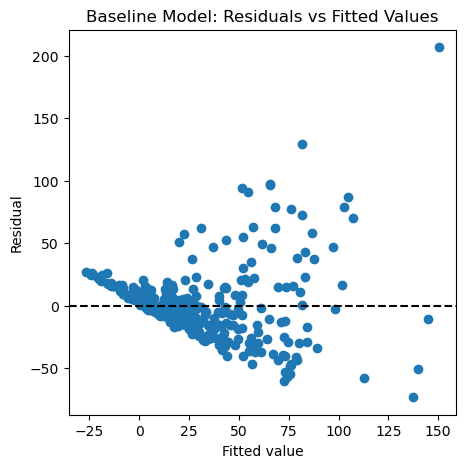

In [46]:
#plot the residual vs predicted value graph
ax = subplots(figsize=(5, 5))[1]

ax.scatter(
    baseline_results.fittedvalues,
    baseline_results.resid
)

# Add the horizontal residual = 0 line
ax.axhline(0, c="k", ls="--")

ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.set_title("Baseline Model: Residuals vs Fitted Values")

plt.show()

The residuals are generally distributed around zero, but the pattern is not completely random. The spread becomes wider as the fitted values increase, and several large positive residuals appear at higher fitted values. This suggests that the linearity assumption may not be fully satisfied and that the model fits high-revenue movies less accurately. If linearity is violated, the model may systematically overpredict or underpredict revenue in some ranges, produce biased predictions, and fail to capture nonlinear relationships between the predictors and opening-weekend revenue.

## Question 9. Calculate and interpret the Durbin-Watson statistic

In [47]:
# Put residuals in release-date order before calculating the DW statistic.


dw_df = df.loc[baseline_data.index, ["release_date"]].copy()
dw_df["residual"] = baseline_results.resid
dw_df.sort_values("release_date").reset_index(drop=True)

dw_statistic = durbin_watson(dw_df["residual"])
print("Durbin-Watson statistic (release-date order):", round(dw_statistic, 4))
 

 

Durbin-Watson statistic (release-date order): 1.9503


After ordering the observations by release date, the Durbin-Watson statistic is 1.9503. Since this value is very close to 2, it suggests little or no autocorrelation among the residuals. In other words, the prediction error for one movie does not appear to be systematically related to the error for the movie released immediately before it. Therefore, the independence assumption appears reasonable for the baseline model.

## Question 10. Assess constant error variance using White's test

In [48]:
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
white_test = het_white(baseline_results.resid, baseline_results.model.exog)

white_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]

white_results = pd.Series(white_test, index=white_labels)
white_results


LM statistic    1.297007e+02
LM p-value      1.366475e-23
F statistic     2.210194e+01
F p-value       1.518326e-29
dtype: float64

The residual-versus-fitted plot shows that the residual spread generally increases as the fitted values increase, suggesting non-constant variance. In White’s test, the null hypothesis is that the errors have constant variance. The LM p-value is approximately 1.37 × 10⁻²³, so there is enough evidence to reject the null hypothesis at the 5% level and conclude that heteroskedasticity is present. If constant variance is violated, the OLS coefficient estimates may remain unbiased, but their standard errors, t-tests, p-values, and confidence intervals may be unreliable.

## Question 11. Assess normality using a Q-Q plot and the Shapiro-Wilk test

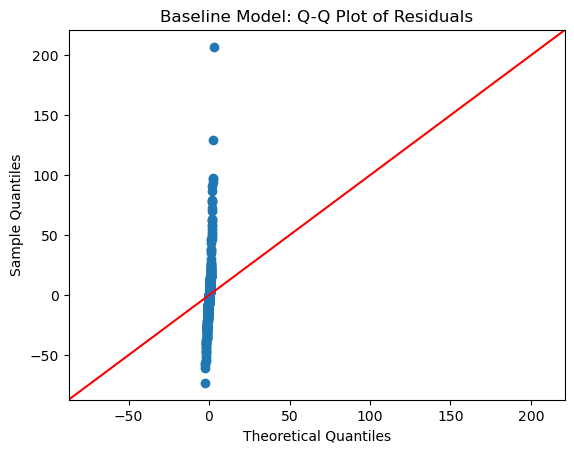

Shapiro-Wilk test statistic: 0.8597
Shapiro-Wilk test p-value: 0.0


In [49]:
sm.qqplot(baseline_results.resid, line="45")
plt.title("Baseline Model: Q-Q Plot of Residuals")
plt.show()

shapiro_result = shapiro(baseline_results.resid)
print("Shapiro-Wilk test statistic:", round(shapiro_result.statistic, 4))
print("Shapiro-Wilk test p-value:", round(shapiro_result.pvalue, 4))

The Q-Q plot shows substantial departures from the 45-degree line. The Shapiro-Wilk test gives W = 0.8597 and p≈0. The null hypothesis is that the residuals are normally distributed. Since the p-value is below 0.05, therefore, we reject the null hypothesis(Normality Assumption). Non-normal residuals can make t-tests, p-values, and confidence intervals less reliable, especially when the deviations are caused by extreme observations.

## Question 12. Identify high-leverage and influential observations

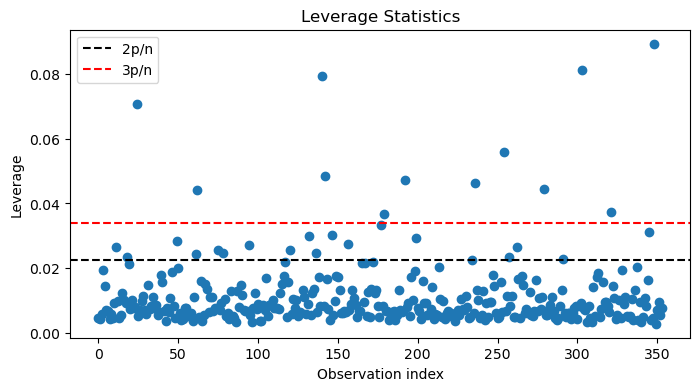

2p/n threshold: 0.0226
3p/n threshold: 0.0339
Movies above 2p/n: 30
Movies above 3p/n: 12


NameError: name 'cooks_distance' is not defined

In [50]:
# Leverage statistics, following the lecture.
influence = baseline_results.get_influence()
leverage = influence.hat_matrix_diag

n = X_baseline.shape[0]
p = X_baseline.shape[1]
leverage_2pn = 2 * p / n
leverage_3pn = 3 * p / n


fig, ax = subplots(figsize=(8, 4))
ax.scatter(np.arange(n), leverage)
ax.axhline(leverage_2pn, color="black", linestyle="--", label="2p/n")
ax.axhline(leverage_3pn, color="red", linestyle="--", label="3p/n")
ax.set_xlabel("Observation index")
ax.set_ylabel("Leverage")
ax.set_title("Leverage Statistics")
ax.legend()
plt.show()

print("2p/n threshold:", round(leverage_2pn, 4))
print("3p/n threshold:", round(leverage_3pn, 4))
print("Movies above 2p/n:", int((leverage > leverage_2pn).sum()))
print("Movies above 3p/n:", int((leverage > leverage_3pn).sum()))
print("Movies above 4/n:",int((cooks_distance > cook_threshold).sum()))


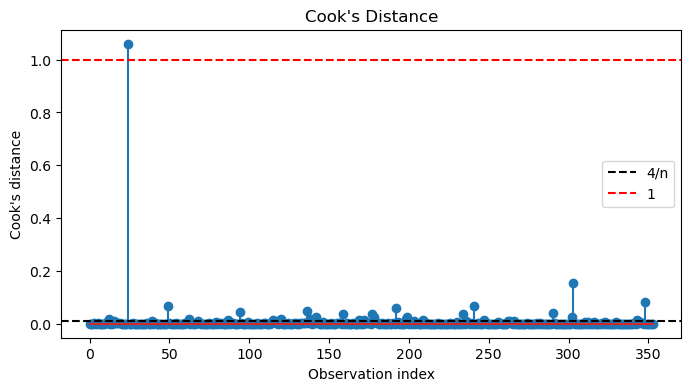

Movies with leverage above 3p/n:


,movie_id,title,production_budget_musd,opening_theaters,runtime_minutes,opening_weekend_revenue_musd,Leverage,Cook's distance
353,TRN-0384,Avatar: Fire and Ash,400.0,3800,197.0,89.1609,0.0894,0.0839
308,TRN-0333,Mission: Impossible—The Final Reckoning,400.0,3857,169.0,64.0364,0.0812,0.1559
143,TRN-0157,Avatar: The Way of Water,400.0,4202,190.0,134.1002,0.0795,0.0032
24,TRN-0029,Avengers: Endgame,400.0,4662,181.0,357.1150,0.0708,1.0604
259,TRN-0281,Devara Part 1,75.0,1040,178.0,5.6000,0.0560,0.0002
145,TRN-0159,Babylon,80.0,3343,188.0,3.6034,0.0484,0.0264
196,TRN-0215,TAYLOR SWIFT | THE ERAS TOUR,15.0,3855,168.0,93.2248,0.0474,0.0614
241,TRN-0261,Horizon: An American Saga Chapter 1,50.0,3334,181.0,11.0526,0.0464,0.0087
284,TRN-0308,Ne Zha 2,80.0,660,143.0,7.2000,0.0446,0.0007
62,TRN-0071,It: Chapter Two,70.0,4570,169.0,91.0622,0.0441,0.0176


Movies with Cook's distance above 4/n:


,movie_id,title,production_budget_musd,opening_theaters,runtime_minutes,opening_weekend_revenue_musd,Leverage,Cook's distance
24,TRN-0029,Avengers: Endgame,400.0,4662,181.0,357.1150,0.0708,1.0604
308,TRN-0333,Mission: Impossible—The Final Reckoning,400.0,3857,169.0,64.0364,0.0812,0.1559
353,TRN-0384,Avatar: Fire and Ash,400.0,3800,197.0,89.1609,0.0894,0.0839
49,TRN-0056,The Lion King,260.0,4725,118.0,191.7708,0.0283,0.0688
246,TRN-0267,Deadpool & Wolverine,200.0,4210,127.0,211.4353,0.0128,0.0668
196,TRN-0215,TAYLOR SWIFT | THE ERAS TOUR,15.0,3855,168.0,93.2248,0.0474,0.0614
139,TRN-0152,Black Panther: Wakanda Forever,250.0,4396,161.0,181.3398,0.0246,0.0485
94,TRN-0103,Star Wars: The Rise of Skywalker,275.0,4406,142.0,177.3839,0.0270,0.0425
295,TRN-0320,A Minecraft Movie,150.0,4263,100.0,162.7530,0.0134,0.0394
239,TRN-0259,Inside Out 2,200.0,4440,100.0,154.2017,0.0226,0.0374


Movies with Cook's distance above 1:


,movie_id,title,production_budget_musd,opening_theaters,runtime_minutes,opening_weekend_revenue_musd,Leverage,Cook's distance
24,TRN-0029,Avengers: Endgame,400.0,4662,181.0,357.115,0.0708,1.0604


In [ ]:
# Cook's distance, following the lecture.
ols_influence = OLSInfluence(baseline_results)
cooks_distance, cooks_pvalue = ols_influence.cooks_distance
cook_threshold = 4 / n

fig, ax = subplots(figsize=(8,4))
ax.stem(np.arange(n), cooks_distance)
ax.axhline(cook_threshold, color="black", linestyle="--", label="4/n")
ax.axhline(1, color="red", linestyle="--", label="1")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance")
ax.legend()
plt.show()

influence_table = df.loc[
    baseline_data.index,
    ["movie_id", "title",
     "production_budget_musd",
     "opening_theaters",
     "runtime_minutes",
     "opening_weekend_revenue_musd"]
].copy()
influence_table["Leverage"] = leverage
influence_table["Cook's distance"] = cooks_distance

very_high_leverage = influence_table[
   influence_table["Leverage"] > leverage_3pn
].sort_values("Leverage", ascending=False)#dataset with leverage greater than 3p/n

large_cook = influence_table[
    influence_table["Cook's distance"] > cook_threshold
].sort_values("Cook's distance", ascending=False) #dataset with leverage  greater than 4/n

serious_cook = influence_table[
    influence_table["Cook's distance"] > 1
].sort_values("Cook's distance", ascending=False)#dataset with leverage greater than 1



print("Movies with leverage above 3p/n:")
display(very_high_leverage.round(4))

print("Movies with Cook's distance above 4/n:")
display(large_cook.round(4))

print("Movies with Cook's distance above 1:")
display(serious_cook.round(4))

The leverage analysis identifies 30 observations above \(2p/n\) and 12 above \(3p/n\), indicating that these movies have unusual combinations of predictor values. Cook’s distance identifies 31 potentially influential observations above \(4/n\). Avengers: Endgame is serious outliers because their Cook’s distances exceed 1, meaning that removing them could substantially change the estimated regression coefficients. Overall, the baseline model has several weaknesses: the residuals are non-normal, the error variance is not constant, and influential observations may strongly affect the estimates. In addition, runtime is insignificant and the model explains only about 52.6% of the variation in opening-weekend revenue.

# Part 4. Design your own regression model

## Question 13. State Y and the candidate X variables before fitting models

**Outcome variable (Y):** `opening_weekend_revenue_musd`, the domestic opening-weekend box-office revenue, measured in millions of US dollars.

**Candidate X variables and rationale:**

1. **production_budget_musd** – Bigger budgets pay for stars, visual effects and heavier marketing, raising awareness and perceived quality.
2. **opening_theaters** – More theaters means more screens and showtimes, so more tickets can be sold on opening weekend.
3. **runtime_minutes** – Longer films are often big "event" films, but they also allow fewer showtimes per day, so the effect is uncertain.
4. **release_quarter** – Demand is seasonal: summer (Q2) and year-end holidays (Q4) draw more moviegoers than Q1.
5. **rating** – G/PG/PG-13 films reach families and teens, a wider audience than R-rated films.
6. **genre** – Action and adventure films attract broad audiences, while dramas and documentaries are more niche.
7. **distributor_group** – Major studios have larger marketing budgets and stronger theater relationships than smaller distributors. Others = 0, major distributors are deemed as a same category = 1.
8. **production_origin** – US-only productions better match domestic tastes than international co-productions.
9. **holiday_release** – People have more free time during holidays, so attendance increases.

No new variables are created at this stage.

| Variable | Type | Hypothesized effect on Y | Expected sign |
|---|---|---|---|
| production_budget_musd | Numeric (USD millions) | Higher budget → more stars, effects and marketing → higher opening revenue | + |
| opening_theaters | Numeric (count) | More theaters → more showtimes and access → higher revenue | + |
| runtime_minutes | Numeric (minutes) | Event-film appeal vs. fewer daily showtimes | Ambiguous (+/−) |
| release_quarter | Categorical (Q1–Q4; base = Q1) | Q2 (summer) and Q4 (holidays) have higher demand than Q1 | Q2, Q4: +; Q3: small + |
| rating | Categorical (G, PG, PG-13, R; base = R) | Less restrictive ratings → broader audience | G/PG/PG-13: + vs. R |
| genre | Categorical | Action/Adventure have mass appeal; Drama/Documentary are niche | Action/Adventure: +; Drama/Documentary: − |
| distributor_group | Categorical (base = Other) | Major studios have bigger marketing and distribution power | Majors: + vs. Other |
| production_origin | Binary (base = US_only) | International co-productions appeal less to domestic audiences | International: − |
| holiday_release | Binary (0/1) | Holiday free time → higher attendance | + |


## Question 14. Write and justify the final regression model

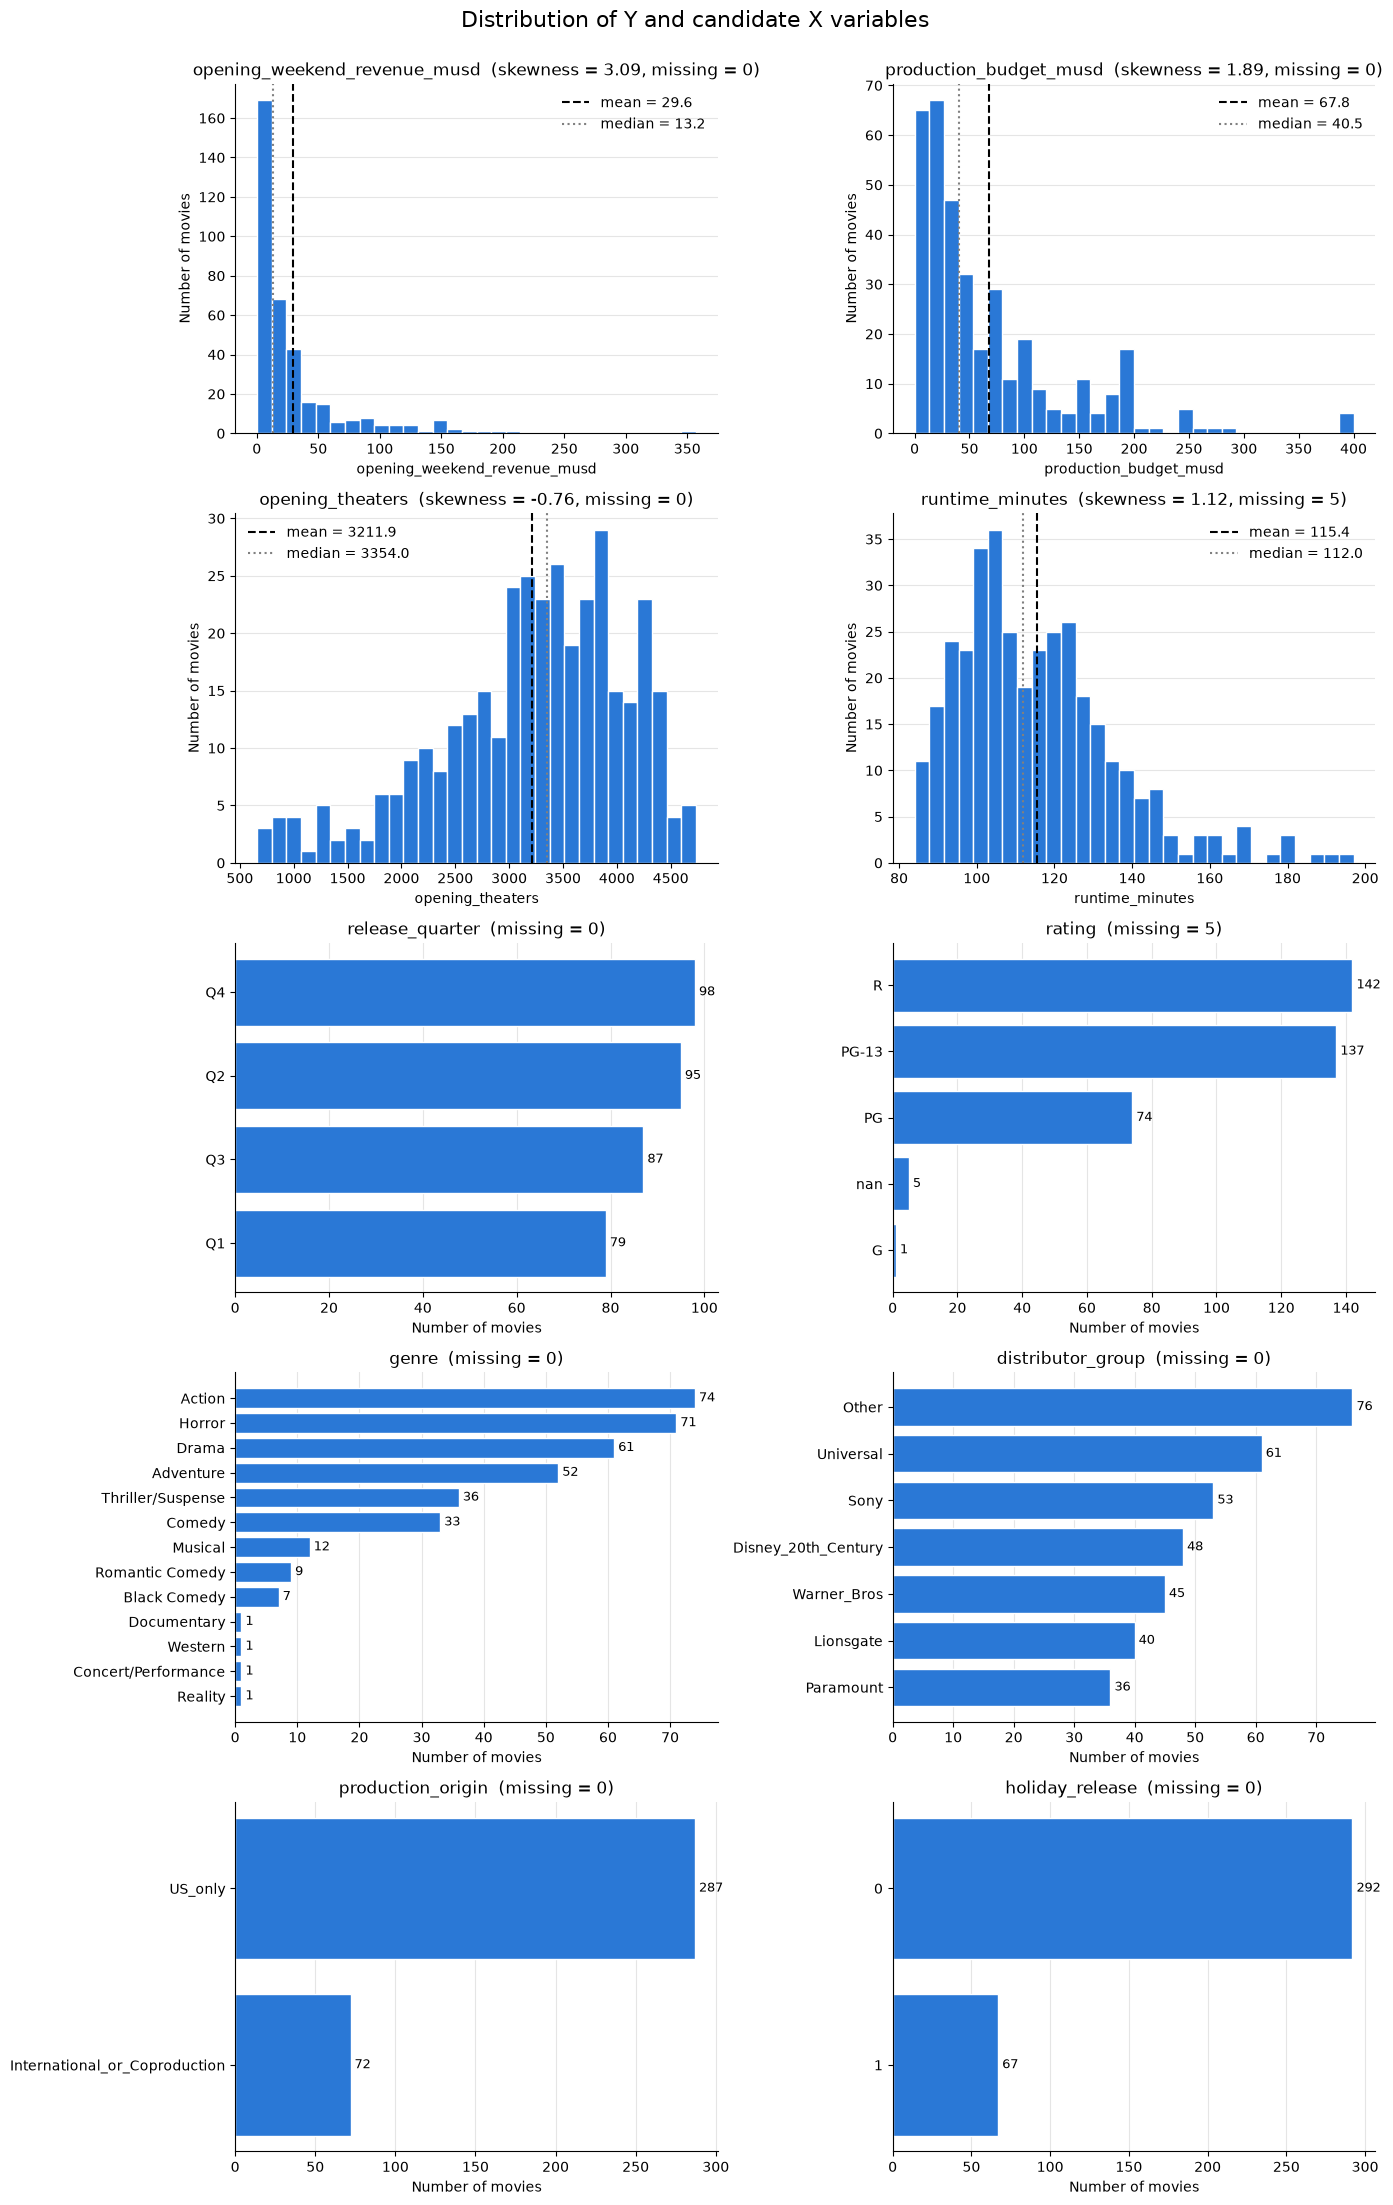

In [ ]:
## Describing the Distribution of Y and Candidate X Variables
import numpy as np
import pandas as pd
from IPython.display import display

df = pd.read_excel('movie_training_data_student.xlsx', sheet_name = 'Training_Data')

model_variables = [
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes",
    "release_quarter",
    "rating",
    "genre",
    "distributor_group",
    "production_origin",
    "holiday_release"
]

bar_color = "#2a78d6"

fig, axes = plt.subplots(5, 2, figsize=(14, 22))

for ax, variable in zip(axes.flatten(), model_variables):
    column = df[variable]
    is_continuous = pd.api.types.is_numeric_dtype(column) and column.nunique() > 2

    # Numeric variables: histogram with mean and median lines
    if is_continuous:
        ax.hist(column.dropna(), bins=30, color=bar_color, edgecolor="white")
        ax.axvline(column.mean(), color="black", linestyle="--", linewidth=1.5,
                   label=f"mean = {column.mean():.1f}")
        ax.axvline(column.median(), color="gray", linestyle=":", linewidth=1.5,
                   label=f"median = {column.median():.1f}")
        ax.set_xlabel(variable)
        ax.set_ylabel("Number of movies")
        ax.legend(frameon=False)
        ax.set_title(f"{variable}  (skewness = {column.skew():.2f}, missing = {column.isna().sum()})")
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)

    # Categorical and binary variables: horizontal bar chart of counts
    else:
        counts = column.astype(str).value_counts().sort_values()
        ax.barh(counts.index, counts.values, color=bar_color, edgecolor="white")
        for y, count in enumerate(counts.values):
            ax.text(count, y, f" {count}", va="center", fontsize=9)
        ax.set_xlabel("Number of movies")
        ax.set_title(f"{variable}  (missing = {column.isna().sum()})")
        ax.grid(axis="x", color="#e5e5e5", linewidth=0.8)

    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

fig.suptitle("Distribution of Y and candidate X variables", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()



**Summary of data transformations**

The outcome variable is strongly right-skewed (skewness = 3.09), so we model log(Y); this makes it nearly symmetric (skewness ≈ 0) and lets coefficients be read as percentage effects. Production budget is also right-skewed, but a log transform over-corrects because of a few tiny budgets, so we first check those values. Opening theaters correlates more strongly with log(Y) in its raw form and is kept linear. The five missing runtimes are dropped. Rare categories in rating and genre are merged using the existing group variables, and every categorical variable is converted into dummy variables with a clear baseline category.

| Variable | Issue observed | Transformation | Rationale |
|---|---|---|---|
| opening_weekend_revenue_musd (Y) | Right-skewed (skew = 3.09); min = 0.25 | Natural log: `log_revenue` | Skew drops to ≈ 0; stabilizes variance; coefficients become % effects |
| production_budget_musd | Right-skewed (skew = 1.89); a few near-zero values | Inspect tiny budgets; consider `log_budget` | Captures diminishing returns; log is only safe after checking the outliers |
| opening_theaters | Mild left skew (−0.76) | Keep linear; add a squared term if residuals curve | Correlates more strongly with log(Y) raw (0.83) than logged (0.76) |
| runtime_minutes | 5 missing values; right-skewed (1.12) | Drop missing rows; optional `runtime²` | Tests a possible inverted-U effect |
| release_quarter | 4 balanced levels | Dummies, baseline = Q1 | Captures seasonal demand |
| rating | G has only 1 movie; 5 missing values | Use `rating_group` (G_or_PG, PG-13, R); baseline = R | Avoids unstable estimates for a level with 1 movie |
| genre | 4 genres with only 1 movie each | Use `genre_group` (7 levels incl. Other) | Gives every level enough observations |
| distributor_group | 7 levels, reasonable sizes | Dummies, baseline = Other; optional `major_studio` flag | Compares major studios against small distributors |
| production_origin | Binary | Dummy, baseline = US_only | Directly tests the domestic-appeal hypothesis |
| holiday_release | Already 0/1 | No change | Already in usable form |


**Final model specification**

$$
\log(\text{Revenue}_i) = \beta_0 + \beta_1\,\text{Budget}_i + \beta_2\,\text{Theaters}_i + \beta_3\,\text{Runtime}_i + \boldsymbol{\gamma}'\text{Quarter}_i + \boldsymbol{\delta}'\text{Rating}_i + \boldsymbol{\theta}'\text{GenreGroup}_i + \lambda\,\text{MajorStudio}_i + \beta_4\,\text{International}_i + \beta_5\,\text{Holiday}_i + \phi\,(\text{Budget}_i \times \text{MajorStudio}_i) + \varepsilon_i
$$

The outcome is log opening-weekend revenue, so coefficients are read as approximate percentage effects. The model keeps all nine candidate predictors, using the grouped rating and genre variables and dummy variables for the categorical predictors (baselines: Q1, R, Other, US_only). We add an interaction between production budget and MajorStudio, which equals 1 for the six named studios and 0 for "Other". Major studios can turn each budget dollar into wider marketing and better screen allocation more effectively than small distributors, so the budget slope should be steeper for majors. The interaction coefficient φ measures how much steeper the budget slope is for major studios than for the "Other" group; we expect φ > 0.


## Question 15. Describe and report the missing-value treatment

In [18]:
final_variables = [
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes",
    "release_quarter",
    "rating",
    "genre_group",
    "distributor_group",
    "production_origin",
    "holiday_release",
]

# Missing values in the model variables only
missing_final = df[final_variables].isna().sum()
print("Missing values in final-model variables:")
print(missing_final[missing_final > 0])

# Which movies are affected
rows_missing = df[final_variables].isna().any(axis=1)
display(df.loc[rows_missing, ["title", "runtime_minutes", "rating"]])

# Drop rows only when a final-model variable is missing
final_data = df.dropna(subset=final_variables).copy()

print("Original observations:", len(df))
print("Observations removed:", int(rows_missing.sum()))
print("Final sample size:", len(final_data))

Missing values in final-model variables:
runtime_minutes    5
rating             5
dtype: int64


,title,runtime_minutes,rating
112,Fantastic Beasts: The Secrets of Dumbledore,NaN,PG-13
114,The Unbearable Weight of Massive Talent,NaN,R
127,Easter Sunday,NaN,PG-13
135,Terrifier 2,138.0,NaN
149,Skinamarink,100.0,NaN
189,The Nun II,NaN,R
208,Migration,NaN,PG
259,Devara Part 1,178.0,NaN
263,Terrifier 3,125.0,NaN
284,Ne Zha 2,143.0,NaN


Original observations: 359
Observations removed: 10
Final sample size: 349


Missing value treatment: We check missing values only in the variables used in our final model, so gaps in unused variables do not cost us observations.

- **Y (opening-weekend revenue):** no missing values.
- **Budget, theaters, release quarter, genre group, distributor group, production origin and holiday release:** no missing values, no treatment needed.
- **Runtime:** 5 movies are missing (e.g., The Nun II, Migration). We drop these rows because runtime cannot be reliably guessed.
- **Rating:** 5 different movies are missing, mostly unrated horror or foreign films (e.g., Terrifier 2, Ne Zha 2). We drop them rather than create a category with only 5 movies.

In total, 10 movies (2.8%) are removed, leaving 349 for estimation. No variable is deleted because of missing data. Audience score and total box-office fields (about 44% missing) are excluded because they are only known after release, not because of their missingness.

## Question 16. Create and display the y vector and X matrix

In [24]:
# Response vector: log of opening-weekend revenue
y = np.log(final_data["opening_weekend_revenue_musd"])
y.name = "log_revenue"

# Numeric predictors enter as they are
X = final_data[["production_budget_musd", "opening_theaters", "runtime_minutes"]].copy()

# Holiday release is already a 0/1 dummy
X["dummy_holiday_release"] = final_data["holiday_release"]

# Categorical predictors become dummies; the baseline level is dropped
baselines = {
    "release_quarter": "Q1",
    "rating": "R",
    "genre_group": "Other",
    "production_origin": "US_only",
}
for variable, baseline in baselines.items():
    dummies = pd.get_dummies(final_data[variable], prefix=f"dummy_{variable}", dtype=int)
    X = X.join(dummies.drop(columns=f"dummy_{variable}_{baseline}"))

# Major studio = 1 for the six named distributors, 0 for "Other"
X["dummy_major_studio"] = (final_data["distributor_group"] != "Other").astype(int)

# Interaction: budget x major studio
X["interaction_budget_x_major"] = X["production_budget_musd"] * X["dummy_major_studio"]

X = sm.add_constant(X).rename(columns={"const": "intercept"})

print("Dimension of y:", y.shape)
print("Dimension of X:", X.shape)
display(y.head(10))
display(X.head(10))

Dimension of y: (349,)
Dimension of X: (349, 20)


0    2.903517
1    2.420480
2    0.865134
3    2.284034
4    3.697069
5    1.970448
6    1.926399
7    2.400640
8    1.766965
9    2.903183
Name: log_revenue, dtype: float64

,intercept,production_budget_musd,opening_theaters,runtime_minutes,dummy_holiday_release,dummy_release_quarter_Q2,dummy_release_quarter_Q3,dummy_release_quarter_Q4,dummy_rating_G,dummy_rating_PG,dummy_rating_PG-13,dummy_genre_group_Action,dummy_genre_group_Adventure,dummy_genre_group_Comedy,dummy_genre_group_Drama,dummy_genre_group_Horror,dummy_genre_group_Thriller/Suspense,dummy_production_origin_International_or_Coproduction,dummy_major_studio,interaction_budget_x_major
0,1.0,9.0,2717,109.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,9.0
1,1.0,61.0,3090,102.0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,61.0
2,1.0,30.0,2329,107.0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0.0
3,1.0,8.5,1247,100.0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0.0
4,1.0,20.0,3841,128.0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,20.0
5,1.0,59.0,3521,132.0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,59.0
6,1.0,15.0,2203,104.0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,15.0
7,1.0,60.0,2630,118.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,60.0
8,1.0,6.0,2530,100.0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0.0
9,1.0,20.0,2912,117.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,20.0


The response vector y is the natural log of opening-weekend revenue (349 × 1). The design matrix X has 349 rows and 20 columns: an intercept; four numeric predictors (budget, theaters, runtime, holiday release); 14 dummy variables for release quarter, rating, genre group, production origin and major studio, each omitting its baseline (Q1, R, Other, US_only, non-major); and one budget × major-studio interaction term. The 349 rows match the sample left after dropping the 10 movies with missing runtime or rating.

## Question 17. Estimate, report, and interpret the final model

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     54.27
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           2.85e-89
Time:                        09:06:45   Log-Likelihood:                -315.05
No. Observations:                 349   AIC:                             670.1
Df Residuals:                     329   BIC:                             747.2
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
intercept                                                -1.0469      0.367     -2.856      0.005      -1.768      -0.326
production_budget_musd                                   -0.0050      0.004     -1.348      0.178      -0.012       0.002
opening_theaters                                          0.0010   6.14e-05     16.549      0.000       0.001       0.001
runtime_minutes                                           0.0047      0.002      2.046      0.042       0.000       0.009
dummy_holiday_release                                    -0.0818      0.140     -0.583      0.560      -0.358       0.194
dummy_release_quarter_Q2                                  0.0083      0.098      0.085      0.932      -0.184       0.201
dummy_release_quarter_Q3                                  0.0038      0.099      0.038      0.970      -0.192       0.199
dummy_release_quarter_Q4                                 -0.0517      0.136     -0.382      0.703      -0.319       0.215
dummy_rating_G                                           -0.1473      0.662     -0.223      0.824      -1.449       1.154
dummy_rating_PG                                           0.1266      0.135      0.938      0.349      -0.139       0.392
dummy_rating_PG-13                                        0.0024      0.083      0.029      0.977      -0.161       0.166
dummy_genre_group_Action                                 -0.1437      0.198     -0.725      0.469      -0.534       0.246
dummy_genre_group_Adventure                              -0.3943      0.193     -2.047      0.041      -0.773      -0.015
dummy_genre_group_Comedy                                 -0.2625      0.199     -1.321      0.187      -0.654       0.128
dummy_genre_group_Drama                                  -0.1536      0.191     -0.803      0.423      -0.530       0.223
dummy_genre_group_Horror                                  0.1441      0.205      0.703      0.482      -0.259       0.547
dummy_genre_group_Thriller/Suspense                      -0.1284      0.209     -0.615      0.539      -0.539       0.282
dummy_production_origin_International_or_Coproduction    -0.0829      0.087     -0.955      0.340      -0.254       0.088
dummy_major_studio                                       -0.1824      0.136     -1.338      0.182      -0.451       0.086
interaction_budget_x_major                                0.0086      0.004      2.369      0.018       0.001       0.016
==============================================================================
Omnibus:                        0.185   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.911   Jarque-Bera (JB):                0.222
Skew:                           0.055   

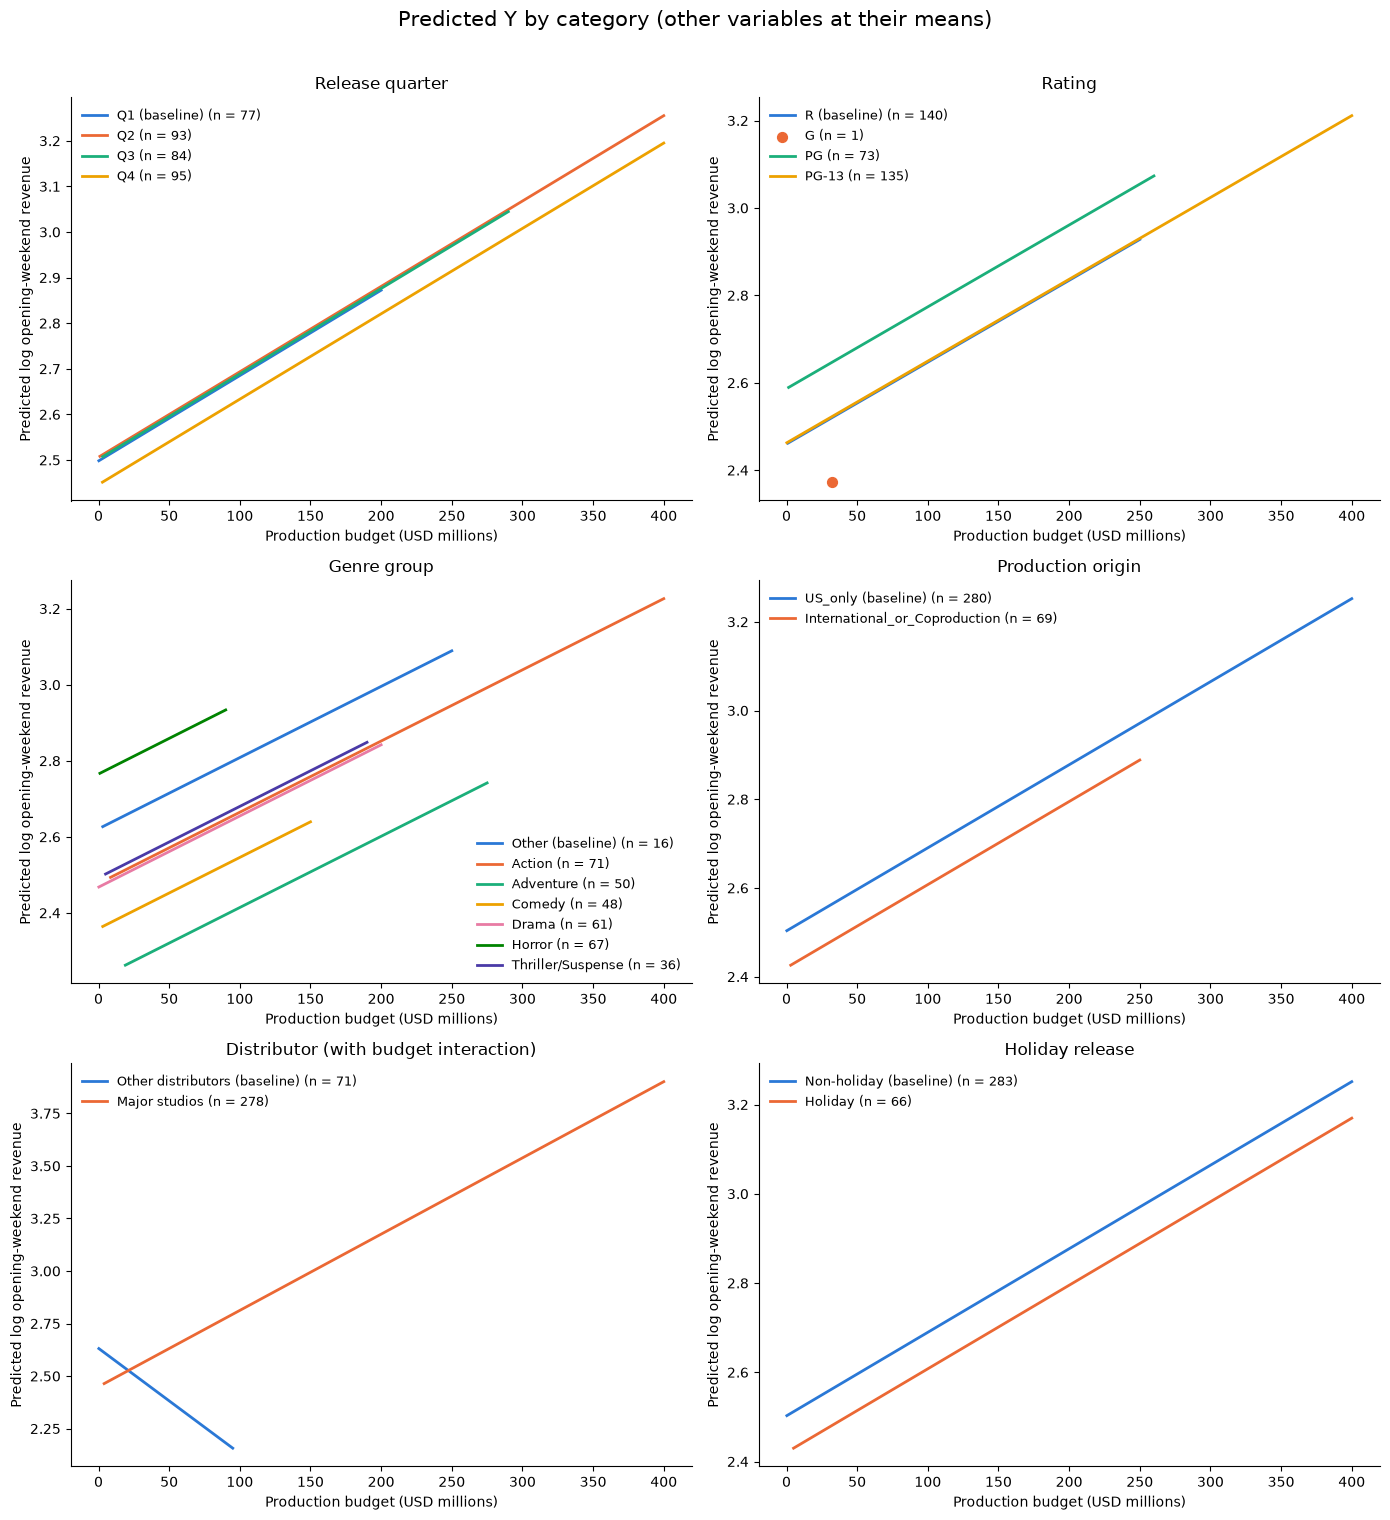

In [25]:
# ======= Estimate the final model =======
final_model = sm.OLS(y, X)
final_results = final_model.fit()
display(final_results.summary())

# ======= Effect of each categorical variable on predicted Y =======
# One line per category: budget varies, every other variable is held at its mean.
# Without an interaction the lines are parallel, so the vertical gap between them
# is that category's intercept shift relative to the baseline.
categorical_groups = {
    "Release quarter": ("dummy_release_quarter_", "Q1"),
    "Rating": ("dummy_rating_", "R"),
    "Genre group": ("dummy_genre_group_", "Other"),
    "Production origin": ("dummy_production_origin_", "US_only"),
    "Distributor (with budget interaction)": ("dummy_major_studio", "Other distributors"),
    "Holiday release": ("dummy_holiday_release", "Non-holiday"),
}
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
X_mean = X.mean()

fig, axes = subplots(3, 2, figsize=(14, 15))

for ax, (title, (prefix, baseline)) in zip(axes.flatten(), categorical_groups.items()):
    dummy_columns = [c for c in X.columns if c.startswith(prefix)]

    # Baseline first (all dummies of this group = 0), then one line per dummy
    categories = [(f"{baseline} (baseline)", None)]
    for column in dummy_columns:
        name = column.removeprefix(prefix)
        if not name:
            name = "Major studios" if column == "dummy_major_studio" else "Holiday"
        categories.append((name, column))

    for color, (name, column) in zip(palette, categories):
        in_category = (X[dummy_columns].sum(axis=1) == 0) if column is None else (X[column] == 1)

        # Draw each line only over the budget range observed in that category
        budgets = X.loc[in_category, "production_budget_musd"]
        budget_grid = np.linspace(budgets.min(), budgets.max(), 100)

        X_line = pd.DataFrame([X_mean] * len(budget_grid))
        X_line["production_budget_musd"] = budget_grid
        X_line[dummy_columns] = 0
        if column is not None:
            X_line[column] = 1
        X_line["interaction_budget_x_major"] = budget_grid * X_line["dummy_major_studio"]

        label = f"{name} (n = {in_category.sum()})"
        if budgets.nunique() == 1:
            # A single observed budget (e.g., one movie) is shown as a point
            ax.scatter(budget_grid[:1], final_results.predict(X_line.iloc[:1]),
                       color=color, s=50, zorder=3, label=label)
        else:
            ax.plot(budget_grid, final_results.predict(X_line), color=color,
                    linewidth=2, label=label)

    ax.set_xlabel("Production budget (USD millions)")
    ax.set_ylabel("Predicted log opening-weekend revenue")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Predicted Y by category (other variables at their means)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Question 18. Evaluate limitations and training-data prediction accuracy

# Part 5. Reflect on the use of AI